In [1]:
#!/usr/bin/env python

import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime
from isoweek import Week
from cmdstanpy import CmdStanModel
from cmdstanpy import from_csv
import glob

In [2]:
# Parse ISO week format (e.g. "2020-W12") into a date (Monday of that ISO week)
def iso_week_to_date(iso_str):
    """
    Convert 'YYYY-Www' string into date.
    Example: "2020-W12" -> Monday of the 12th ISO week of 2020.
    """
    match = re.match(r"(\d{4})-W(\d{1,2})", iso_str)
    if not match:
        return None
    year, week = match.groups()
    year, week = int(year), int(week)
    return Week(year, week).monday()

In [4]:
# Read the 2010-2025 DK data
df = pd.read_csv("data/DK_2010_2025_posfrac.csv", dtype=str)
df["value"] = pd.to_numeric(df["PosFrac"])

# Create a 'date' column from 'year_Week'
df["date"] = df["year_Week"].apply(iso_week_to_date)
df['date'] = pd.to_datetime(df["date"])

print(df['date'])

0     2010-01-04
1     2010-01-11
2     2010-01-18
3     2010-01-25
4     2010-02-01
         ...    
793   2025-02-24
794   2025-03-03
795   2025-03-10
796   2025-03-17
797   2025-03-24
Name: date, Length: 798, dtype: datetime64[ns]


In [5]:
len(df['date'])

798

In [6]:
# Load in stan data:
csv_files = glob.glob('stan_output/stochastic_2025/*20250807144533*.csv')

print(csv_files)

fit = from_csv(csv_files)

['stan_output/stochastic_2025/sirs_stoch_dt_outside_npi_infrequent_constrained-20250807144533_1.csv', 'stan_output/stochastic_2025/sirs_stoch_dt_outside_npi_infrequent_constrained-20250807144533_2.csv', 'stan_output/stochastic_2025/sirs_stoch_dt_outside_npi_infrequent_constrained-20250807144533_4.csv', 'stan_output/stochastic_2025/sirs_stoch_dt_outside_npi_infrequent_constrained-20250807144533_3.csv']


In [7]:
print(fit.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [8]:
for var in ['S0', 'logx_I0', 'beta0', 'dbeta', 'betaphase', 'sigma_obs', 'rho', 'delta']:
#for var in ['S0', 'I0', 'beta0', 'dbeta', 'betaphase', 'sigma_obs', 'rho', 'tau']:
    print(f"{var}: {fit.stan_variable(var).mean()}")

S0: 0.593689051
logx_I0: -2.4451603566666664
beta0: 0.7147070171666667
dbeta: 0.17543598633333332
betaphase: 3.5202163216666666
sigma_obs: 0.007743773563333334
rho: 0.023278438216666666
delta: 0.002210908995


In [9]:
import arviz as az

# Convert your CmdStanPy 'fit' object to an ArviZ InferenceData:
idata = az.from_cmdstanpy(fit)
for var in ['S0', 'logx_I0', 'I0', 'beta0', 'dbeta', 'betaphase', 'sigma_obs', 'sigmaW', 'rho', 'delta']:
    # Suppose you want the HPD interval
    hpd = az.hdi(idata, var_names=[var], hdi_prob=0.95)

    print(f"{var}: {fit.stan_variable(var).mean()}" + "\t\t" + f"[{np.float64(hpd[var][0])} ; {np.float64(hpd[var][1])}]")
    if var=="delta":
        print(f"1/{var}: {(1/52)*1/fit.stan_variable(var).mean()} years" + "\t\t" + f"[{(1/52)*1/np.float64(hpd[var][1])} ; {(1/52)*1/np.float64(hpd[var][0])}]")

S0: 0.593689051		[0.538487 ; 0.646941]
logx_I0: -2.4451603566666664		[-2.58631 ; -2.28755]
I0: 0.002160367505		[0.00141182 ; 0.00287627]
beta0: 0.7147070171666667		[0.651295 ; 0.774795]
dbeta: 0.17543598633333332		[0.154077 ; 0.197629]
betaphase: 3.5202163216666666		[3.38905 ; 3.64255]
sigma_obs: 0.007743773563333334		[0.00730593 ; 0.00821861]
sigmaW: 0.12003685585000001		[0.105303 ; 0.134252]
rho: 0.023278438216666666		[0.0182693 ; 0.0281444]
delta: 0.002210908995		[0.00159751 ; 0.00280373]
1/delta: 8.698127907688589 years		[6.858994707325325 ; 12.037964852031745]


sigmaW posterior mean +- sd: 0.120037 +- 0.007437


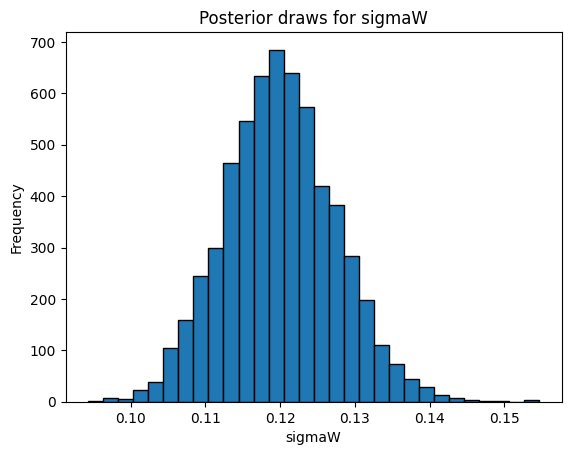

In [10]:
# Extract draws for variable:
#var = 'sigma_obs'
#var = 'rho'
#var = 'beta0'
#var = 'betaphase'
#var = 'dbeta'
#var = 'delta'
var = 'sigmaW'
#var = 'I0'
#var = 'S0'
#var = 'x_I0'
#var = 'logx_I0'
#var = 'T'




v_samples = fit.stan_variable(var)

# Compute mean and standard deviation:
mean_v = v_samples.mean()
sd_v = v_samples.std()

print(f"{var} posterior mean +- sd: {mean_v:.6f} +- {sd_v:.6f}")
if var=='delta':
    print(f"1/(mean({var})) = {1/mean_v:.3f} weeks = {(1/52)*1/mean_v:.3f} years")
    print(f"+ standard deviation: 1/(mean({var})) = {1/(mean_v+sd_v):.3f} weeks = {(1/52)*1/(mean_v+sd_v):.3f} years")
    print(f"- standard deviation: 1/(mean({var})) = {1/(mean_v-sd_v):.3f} weeks = {(1/52)*1/(mean_v-sd_v):.3f} years")

plt.hist(v_samples, bins=30, edgecolor='k')
plt.title("Posterior draws for " + var)
plt.xlabel(var)
plt.ylabel("Frequency")
plt.show()


1317


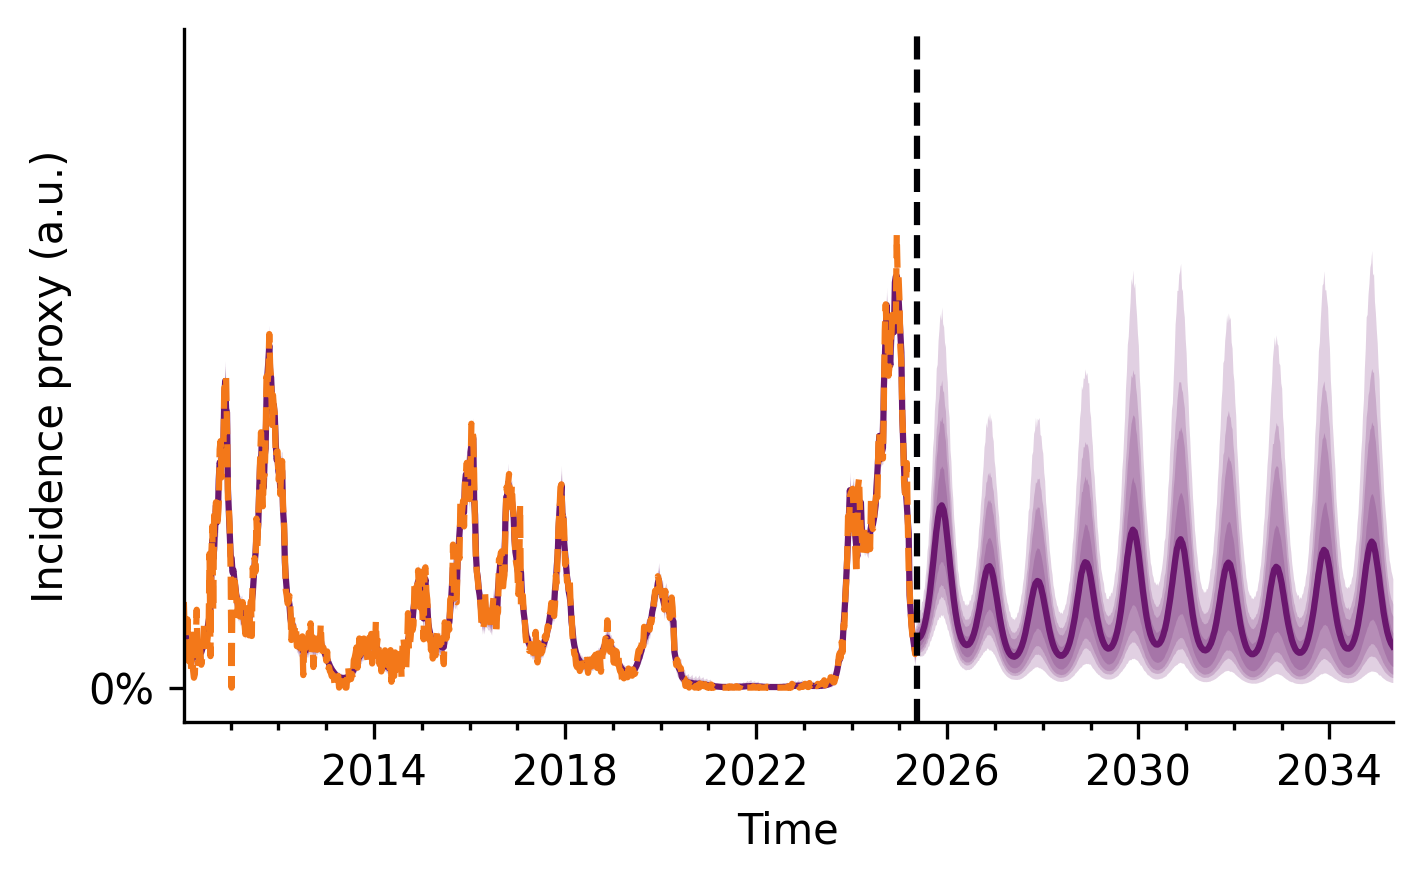

In [11]:
var = "Ifit"


include_xticks = True

v_draws = fit.stan_variable(var)
print(v_draws.shape[1])

plt.figure(figsize=(5.2, 3), dpi=300)

############

mean_v = np.mean(v_draws, axis=0)  # average over draws
lower_v = np.percentile(v_draws, 2.5, axis=0)  # 2.5% quantile
upper_v = np.percentile(v_draws, 97.5, axis=0) # 97.5% quantilel

time_fit = np.arange(1, v_draws.shape[1] + 1)/52 + 2010
time_data = np.arange(1, len(df['value']) + 1)/52 + 2010

plt.plot(time_fit, mean_v, label='Posterior Mean', color=plt.cm.inferno(0.3))


plt.fill_between(time_fit, lower_v, upper_v, color=plt.cm.inferno(0.3), alpha=0.2, label='95% CI', lw=0)
for ci in [85, 75, 50]:
    ci_lower = (100-ci)/2
    ci_upper = ci + (100-ci)/2
    lower_v = np.percentile(v_draws, ci_lower, axis=0) 
    upper_v = np.percentile(v_draws, ci_upper, axis=0)
    plt.fill_between(time_fit, lower_v, upper_v, color=plt.cm.inferno(0.3), alpha=0.2, lw=0)

#plt.plot(df['value'] / (np.mean(fit.stan_variable("rho"))), label="data" )
plt.plot(time_data, df['value'], "--", label="Data", color=plt.cm.inferno(0.7))

prediction_start_date = time_data[-1]+1/52
color = plt.cm.inferno(0.0)
plt.axvline(prediction_start_date, ls="--", color=color, label="Prediction begins")

plt.xticks(np.arange(2010,2035))
xticklabels = []
ax=plt.gca()
n=4
for i, tick in enumerate(ax.xaxis.get_major_ticks()):
    if i % n == 0:
        tick.tick1line.set_markersize(4)  # tick length
        tick.tick2line.set_markersize(4)
        if include_xticks:
            xticklabels.append(i+2010)
        else:
            xticklabels.append('')
    else:
        tick.tick1line.set_markersize(2)  # tick length
        tick.tick2line.set_markersize(2)
        xticklabels.append('')

plt.xticks(np.arange(2010,2035), labels=xticklabels)
plt.yticks([0], labels=['0%'])
if include_xticks:
    plt.xlabel('Time')

plt.ylabel("Incidence proxy (a.u.)")


#plt.legend(loc="upper left")

plt.ylim([-0.021, 0.4])
plt.xlim([time_fit[0], time_fit[-1]])

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.show()


1317


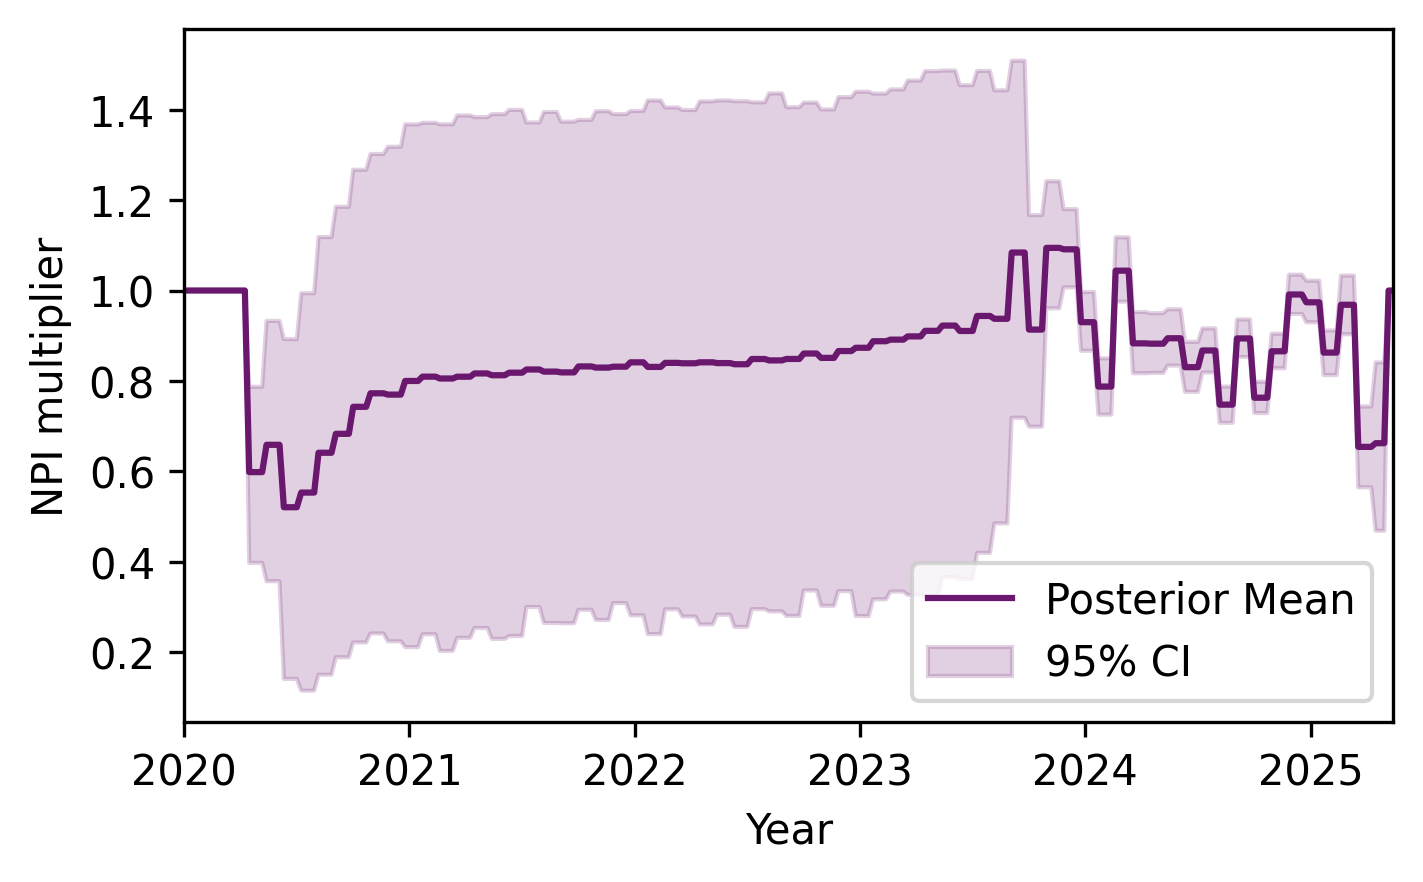

In [12]:
var = "npieff"

v_draws = fit.stan_variable(var)
print(v_draws.shape[1])

plt.figure(figsize=(5.2, 3), dpi=300)

############

mean_v = np.mean(v_draws, axis=0)  # average over draws
lower_v = np.percentile(v_draws, 2.5, axis=0)  # 2.5% quantile
upper_v = np.percentile(v_draws, 97.5, axis=0) # 97.5% quantile

time_fit = np.arange(1, v_draws.shape[1] + 1)/52 + 2010
time_data = np.arange(1, len(df['value']) + 1)/52 + 2010

plt.plot(time_fit, mean_v, label='Posterior Mean', color=plt.cm.inferno(0.3))


plt.fill_between(time_fit, lower_v, upper_v, color=plt.cm.inferno(0.3), alpha=0.2, label='95% CI')

#plt.plot(df['value'] / (np.mean(fit.stan_variable("rho"))), label="data" )
#plt.plot(time_data, df['value'], "--", label="data", color=plt.cm.inferno(0.7))
plt.xlabel('Year')
plt.ylabel('NPI multiplier')
#plt.title('Posterior Mean and 95% CI for ' + var)
plt.legend()

plt.xlim([2020, 2025+4.4/12])

plt.show()


# Per-chain time-series:

In [22]:
import numpy as np
import matplotlib.pyplot as plt

#var = "I"
var = "Ifit"
#var = "beta"

#var = "npi"
S_draws_all = fit.stan_variable(var)

num_chains = fit.chains

draws_per_chain = S_draws_all.shape[0] // num_chains

S_draws_per_chain = S_draws_all.reshape(
    (num_chains, draws_per_chain, S_draws_all.shape[1])
)


Max of chain 1: 0.24999037133333335 (multiplied by 6e6: 1499942.0)
Max of chain 2: 0.2501453986666667 (multiplied by 6e6: 1500872.0)
Max of chain 3: 0.25003648333333334 (multiplied by 6e6: 1500219.0)
Max of chain 4: 0.25004028333333334 (multiplied by 6e6: 1500242.0)


(0.0, 0.5)

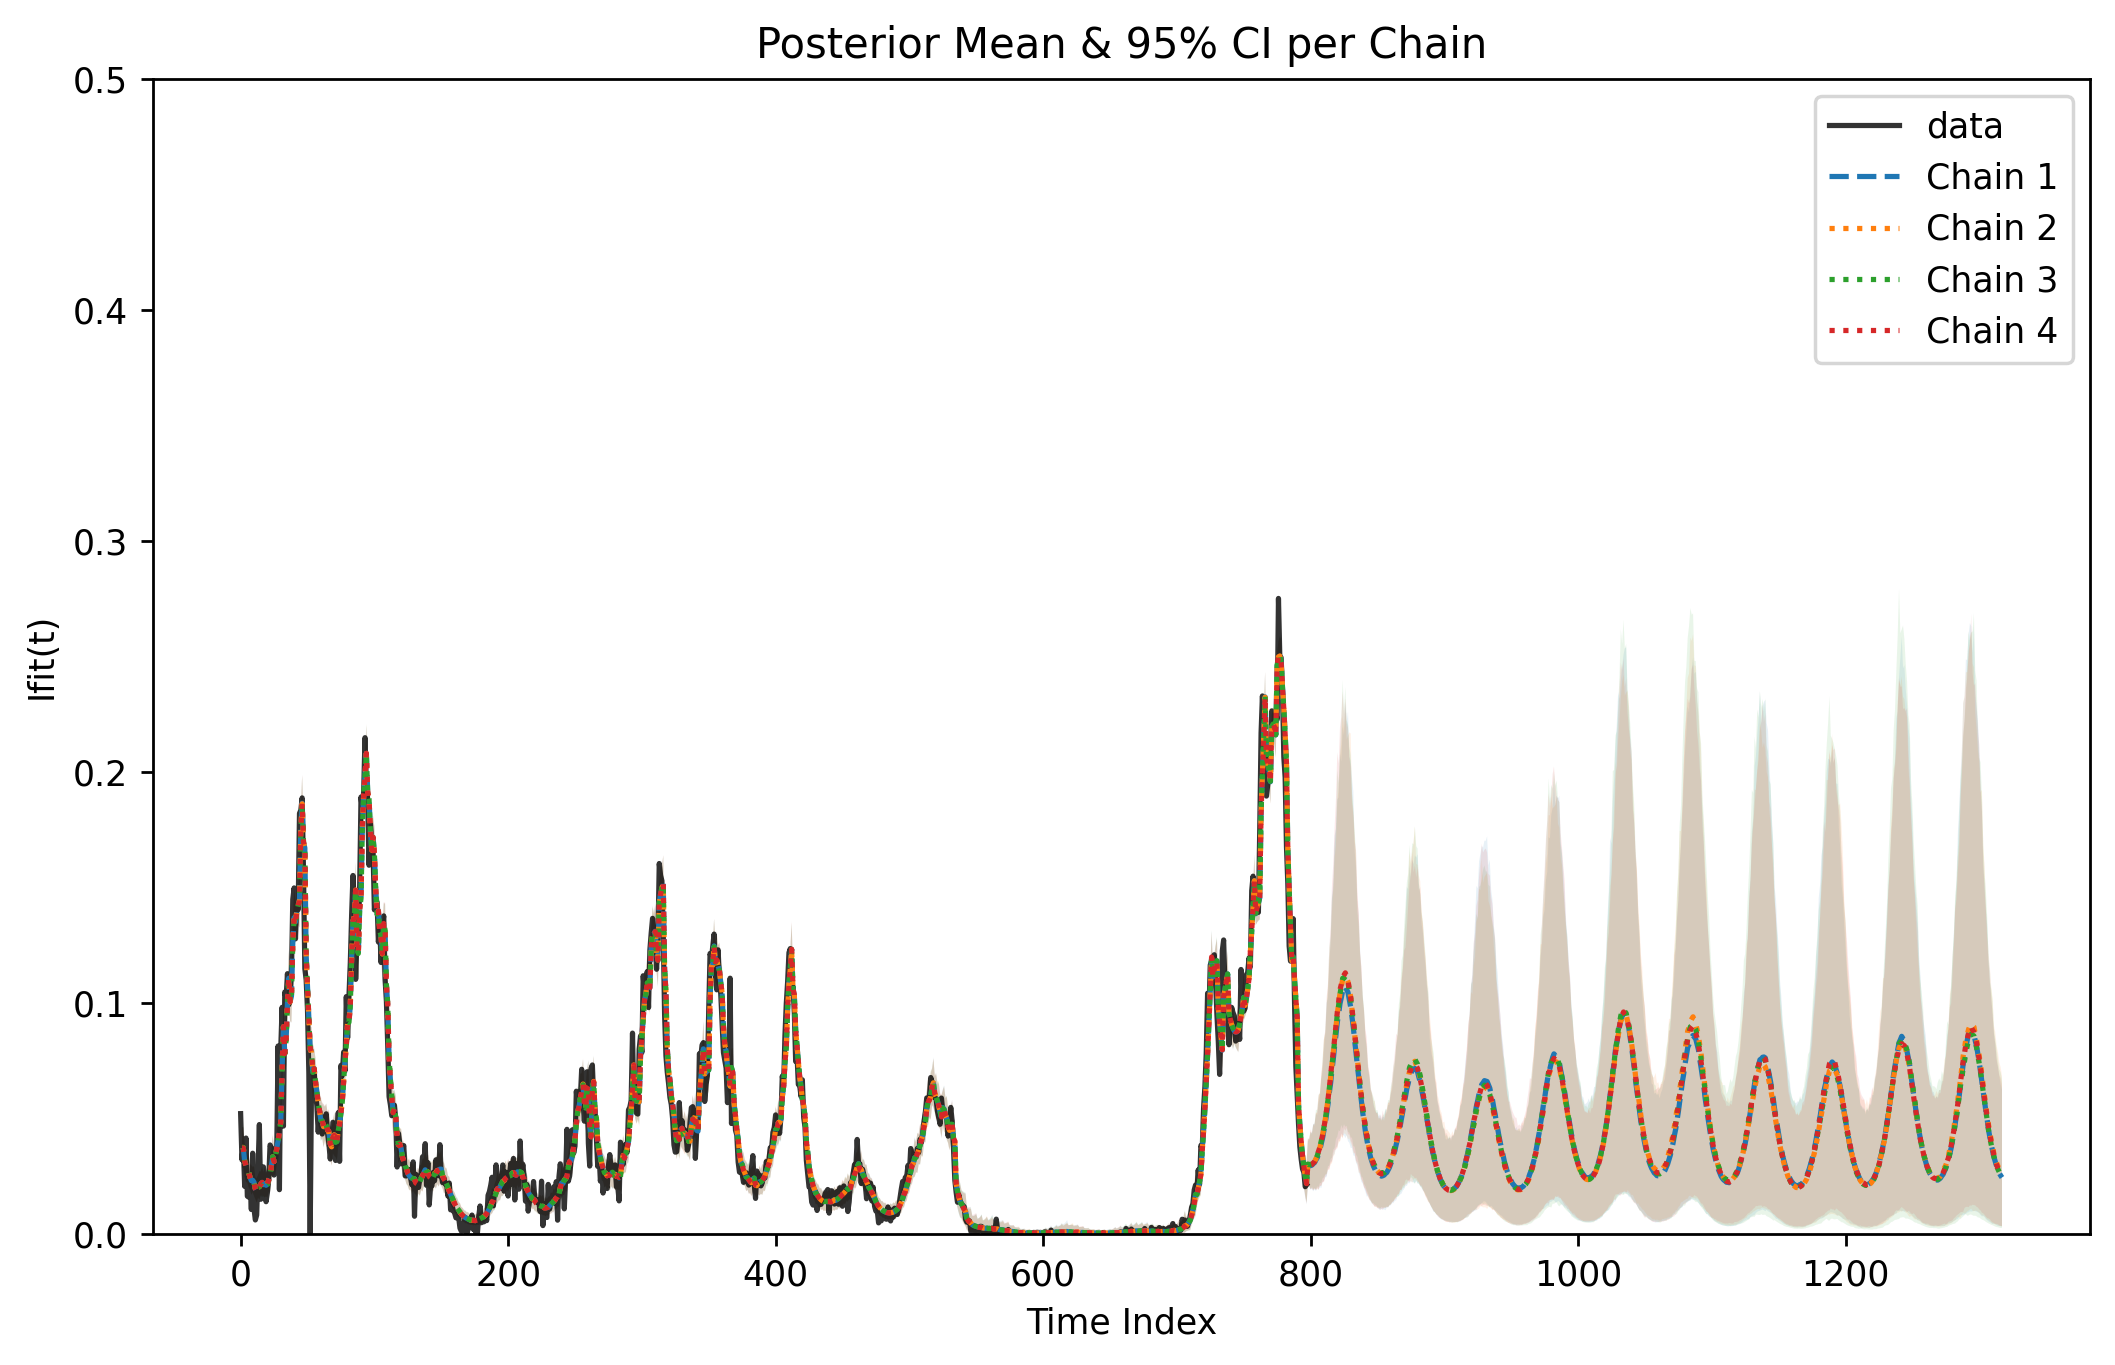

In [16]:
time_idx = np.arange(1, S_draws_per_chain.shape[2] + 1)

plt.figure(figsize=(10, 6), dpi=250)

plot_data = True

excluded_chains = []
#excluded_chains = [1,3,2]


if plot_data:
    plt.plot(df['value'], label="data", color='black', alpha=0.8)

for c in range(num_chains):
    if not (c+1 in excluded_chains):
        chain_data = S_draws_per_chain[c, :, :]  # shape: (draws_per_chain, time_points)
        chain_mean = chain_data.mean(axis=0)
        chain_lower = np.percentile(chain_data, 2.5, axis=0)
        chain_upper = np.percentile(chain_data, 97.5, axis=0)
        print(f"Max of chain {c+1}: {np.max(chain_mean)} (multiplied by 6e6: {np.round(np.max(chain_mean)*6e6)})")
    
        if c+1 < num_chains/2:
            plt.plot(time_idx, chain_mean, "--", label=f'Chain {c+1}')
        else:
            plt.plot(time_idx, chain_mean, ":", label=f'Chain {c+1}')
        plt.fill_between(time_idx, chain_lower, chain_upper, alpha=0.1)

plt.xlabel("Time Index")
plt.ylabel(f"{var}(t)")
plt.title("Posterior Mean & 95% CI per Chain")
plt.legend()

plt.ylim([0, 0.5])

#plt.yscale('log')


In [17]:
chain_of_interest = 1
df_draws = fit.draws_pd()

for var in ['S0', 'logx_I0', 'beta0', 'dbeta', 'betaphase', 'sigma_obs', 'logrho', 'delta']:
    c = chain_of_interest-1
    chain_subset = df_draws.iloc[c*draws_per_chain:(c+1)*draws_per_chain]
    mm = np.mean(chain_subset[var].values)
    sd = np.std(chain_subset[var].values)
    print(f"{var}: {mm}")
    if var == "logx_I0":
        print(f"\t(I0 = {10**mm * np.mean(chain_subset["S0"].values)})")
    if var=='delta':
        print(f"1/(mean({var})) = {1/mm:.3f} weeks = {(1/52)*1/mm:.3f} years")
        print(f"+ standard deviation: 1/(mean({var})) = {1/(mm+sd):.3f} weeks = {(1/52)*1/(mm+sd):.3f} years")
        print(f"- standard deviation: 1/(mean({var})) = {1/(mm-sd):.3f} weeks = {(1/52)*1/(mm-sd):.3f} years")

S0: 0.5973844653333333
logx_I0: -2.4499486800000003
	(I0 = 0.002119850553318101)
beta0: 0.7120777813333334
dbeta: 0.1755951726666667
betaphase: 3.5173641533333333
sigma_obs: 0.007738250866666666
logrho: -1.6345626466666665
delta: 0.002216075946666667
1/(mean(delta)) = 451.248 weeks = 8.678 years
+ standard deviation: 1/(mean(delta)) = 396.895 weeks = 7.633 years
- standard deviation: 1/(mean(delta)) = 522.850 weeks = 10.055 years


# Pairwise posterior plots

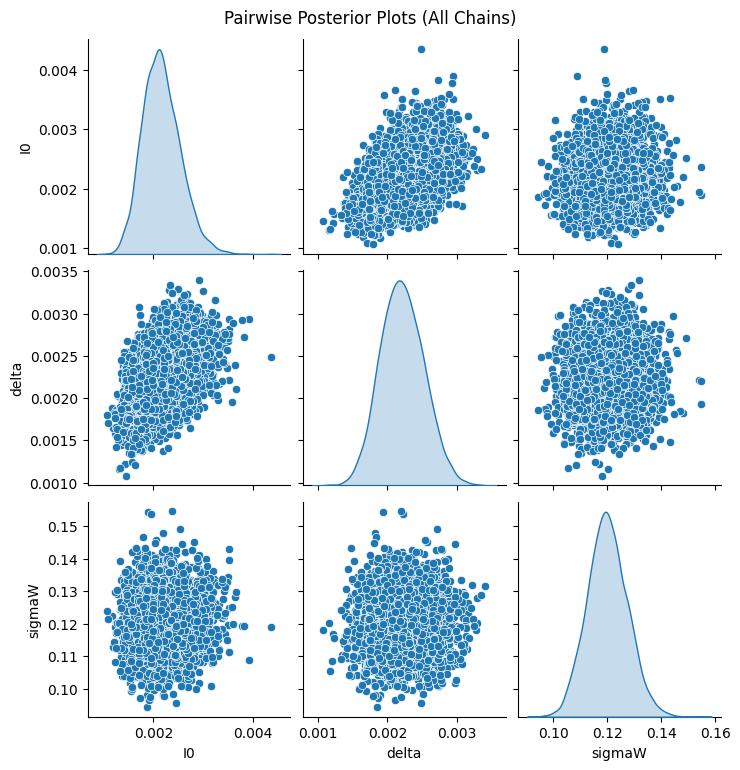

In [23]:
df_draws = fit.draws_pd()

params_of_interest = ["I0", "delta", "sigmaW"] 

df_subset = df_draws[params_of_interest]

sns.pairplot(df_subset, diag_kind="kde")
plt.suptitle("Pairwise Posterior Plots (All Chains)", y=1.02)
plt.show()


In [19]:
# Per-chain

In chain 1, averages were: sigmaW : 0.11977552006666667,   rho : 0.0233332698  (mean product: 0.002794034978933353)


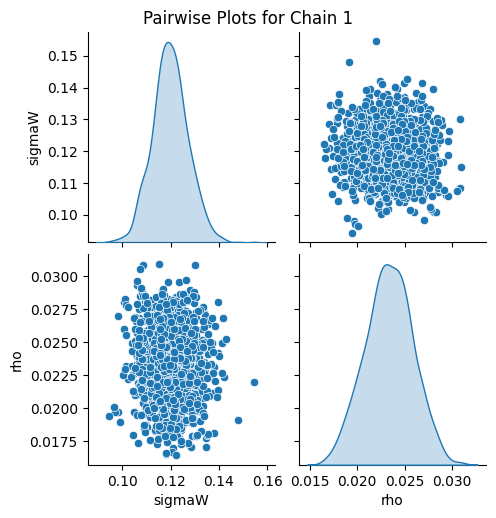

In chain 2, averages were: sigmaW : 0.12024156646666667,   rho : 0.023314520933333333  (mean product: 0.0028049210525672333)


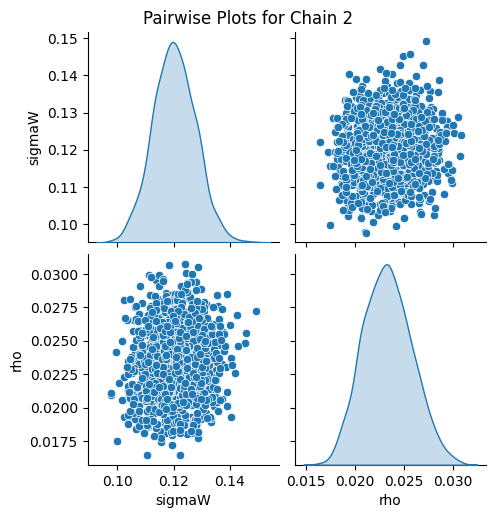

In chain 3, averages were: sigmaW : 0.12063999886666667,   rho : 0.02327712646666667  (mean product: 0.00280815077707328)


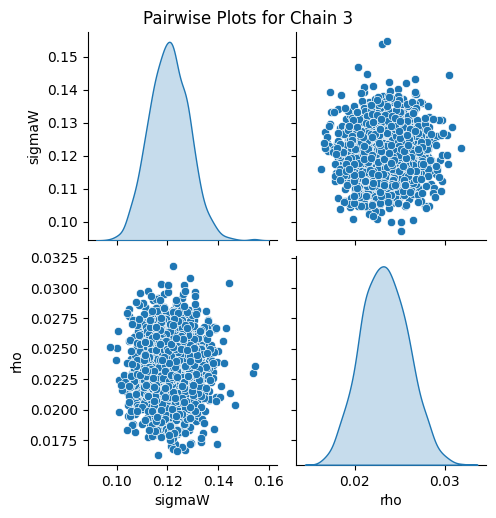

In chain 4, averages were: sigmaW : 0.11949033799999999,   rho : 0.023188835666666668  (mean product: 0.0027722285406169334)


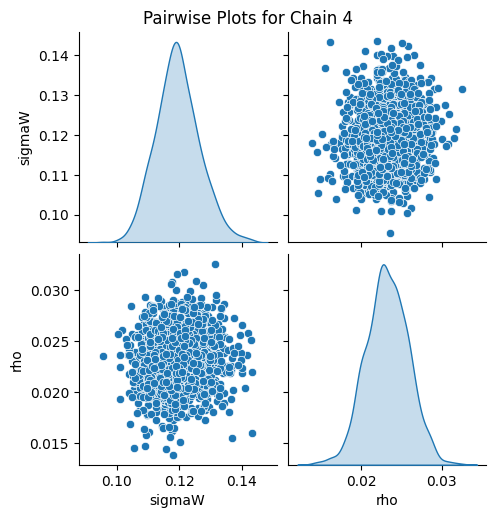

In [20]:
params_of_interest = ["sigmaW", "rho"]
#params_of_interest = ["S0", "I0"]
#params_of_interest = ["T", "delta"]
#params_of_interest = ["betaphase", "delta"]
#params_of_interest = ["beta0", "rho"]

for c in range(num_chains):
    chain_subset = df_draws.iloc[c*draws_per_chain:(c+1)*draws_per_chain]
    # chain_subset now holds rows for chain c
    p1 = params_of_interest[0]
    p2 = params_of_interest[1]
    mp = np.mean(chain_subset[params_of_interest[0]].values*chain_subset[params_of_interest[1]].values)
    print(f"In chain {c+1}, averages were: {params_of_interest[0]} : {chain_subset[params_of_interest[0]].mean()},   {params_of_interest[1]} : {chain_subset[params_of_interest[1]].mean()}  (mean product: {mp})")
    for p in [p1, p2]:
        if p in ["delta"]:
            print(f"1/{p} = {1/np.mean(chain_subset[p].values)}")
    sns.pairplot(chain_subset[params_of_interest], diag_kind="kde")
    plt.suptitle(f"Pairwise Plots for Chain {c+1}", y=1.02)
    plt.show()


df_draws